In [74]:
import numpy as np
from scipy.constants import h, c, k
from scipy.integrate import quad
from scipy.interpolate import interp1d
import pandas as pd 
import matplotlib.pyplot as plt
from pathlib import Path
import os
import datetime
import csv
from datetime import datetime

In [191]:
# === SETTINGS ===
ID = "A10"  # Station ID

# === File Paths ===
dir_path = Path.cwd()  # current working directory
print("Current working directory:", dir_path)

# Data directory 
data_dir = dir_path.parent / "data"
# Protocols directory 
protocol_dir = dir_path.parent / "protocols"
# Halobates data directory 
halobates_dir =  data_dir / "halobates_data"
# Plots directory 
plots_dir = dir_path.parent / "results" / "plots" 
# Output directory for results
results_dir = dir_path.parent / "results" 
# Raw SST temperature directory
out_dir = dir_path / "raw"
# Averaged SST temperature directory
out_dir_avg = dir_path / "1min"


# Halobates protocol file
protocol_file = sorted(protocol_dir.glob(f"*{ID}_17_CST_Schedule.csv"))
protocol_file  = str(protocol_file[0])

# SST temperature file 
sst_file = sorted(out_dir.glob(f"*{ID}_17_IR_SST.csv"))
sst_file  = str(sst_file[0])

# Halobates file
halobates_file = sorted(halobates_dir.glob(f"{ID}_Halobates.csv"))
halobates_file  = str(halobates_file[0])

# Output path for SST vs SML data
sst_sml_output_file = results_dir / "SST_vs_SML.csv"

# === Debug output (optional) ===
print("Halobates data file:", halobates_file)
print("Halobates protocol file:", protocol_file)

Current working directory: c:\Users\ludog\Nextcloud\CLEWS\work\METEOR\IR Camera\github\Infrared_cameras\postproc


IndexError: list index out of range

### Clip SST temperatures based on Halobates protocol

In [192]:
# Load Halobates protocol file
df_protocol = pd.read_csv(
    protocol_file,
    sep=';',
    parse_dates=['Start', 'End'],
    dayfirst=True
)

# Create a 'Type' column:
# – if 'Event' contains 'Deployment', mark as deployment
# – elif 'Event' contains 'Bridge', mark as bridge
# – else mark everything else as intervention
df_protocol['Type'] = np.where(
    df_protocol['Event'].str.contains('Deployment', case=False, na=False),
    'deployment',
    np.where(
        df_protocol['Event'].str.contains('Bridge', case=False, na=False),
        'bridge',
        'intervention'
    )
)

# Drop the original Event column
df_protocol = df_protocol[['Type', 'Start', 'End']]

print(df_protocol)


           Type               Start                 End
0    deployment 2025-07-14 08:20:00 2025-07-14 20:10:00
1        bridge 2025-07-14 08:21:00 2025-07-14 20:09:00
2  intervention 2025-07-14 08:36:00 2025-07-14 08:39:00
3  intervention 2025-07-14 08:46:00 2025-07-14 08:48:00
4  intervention 2025-07-14 09:37:00 2025-07-14 09:41:00
5  intervention 2025-07-14 10:16:00 2025-07-14 10:21:00
6  intervention 2025-07-14 13:53:00 2025-07-14 13:55:00
7  intervention 2025-07-14 19:16:00 2025-07-14 19:19:00
8  intervention 2025-07-14 20:02:00 2025-07-14 20:07:00


In [193]:
# Load SST data
df_sst = pd.read_csv(sst_file, parse_dates=['Time'])

df_sst.head()


ValueError: Invalid file path or buffer object type: <class 'list'>

In [171]:
# Updated function to handle the cases of multiple deployments in the same station
# Masks all times within intervention periods and looks for ealy spiked within 5 minutes from the intervention starts

def compute_threshold(ts: pd.Series, start: pd.Timestamp, end: pd.Timestamp, num_std: float = 2) -> float:
    ref = ts[start:end]
    return ref.mean() + num_std * ref.std()

def clean_sst_multideploy(
    df_sst: pd.DataFrame,
    df_protocol: pd.DataFrame,
    sst_variable: str,
    shift_s: int = 300
) -> pd.DataFrame:
    # Timestamp‐index your SST
    df = df_sst.copy()
    df["Time"] = pd.to_datetime(df["Time"])
    df = df.set_index("Time").sort_index()
    ts = df[sst_variable]

    cleaned_segments = []

    # loop each deployment block
    for _, dep in df_protocol[df_protocol["Type"] == "deployment"].iterrows():
        dep_start, dep_end = dep["Start"], dep["End"]
        # find its bridge rows (there should be one per deployment)
        bridges = df_protocol[
            (df_protocol["Type"] == "bridge") &
            (df_protocol["Start"] >= dep_start) &
            (df_protocol["End"]   <= dep_end)
        ]
        # if no bridge, treat whole deployment as one segment
        if bridges.empty:
            segments = [(dep_start, dep_end)]
        else:
            segments = [(b["Start"], b["End"]) for _, b in bridges.iterrows()]

        # within each bridge segment, mask interventions
        for seg_start, seg_end in segments:
            segment = ts[seg_start:seg_end].copy()
            intervs = df_protocol[
                (df_protocol["Type"] == "intervention") &
                (df_protocol["Start"] >= seg_start) &
                (df_protocol["End"]   <= seg_end)
            ]
            for _, iv in intervs.iterrows():
                sched_start, sched_end = iv["Start"], iv["End"]
                baseline_start = sched_start - pd.Timedelta(seconds=shift_s)
                # compute threshold on clean baseline
                thresh = compute_threshold(segment, baseline_start, sched_start)
                # look back for early spikes
                pre = segment[baseline_start:sched_start]
                spikes = pre[pre > thresh]
                actual_start = spikes.index.min() if not spikes.empty else sched_start
                # mask the full intervention interval
                segment.loc[actual_start:sched_end] = np.nan
            cleaned_segments.append(segment)
    # concatenate all cleaned bridge blocks
    if cleaned_segments:
        cleaned = pd.concat(cleaned_segments).sort_index()
    else:
        cleaned = pd.Series(dtype=float, name=sst_variable)

    return cleaned.reset_index(name=sst_variable)

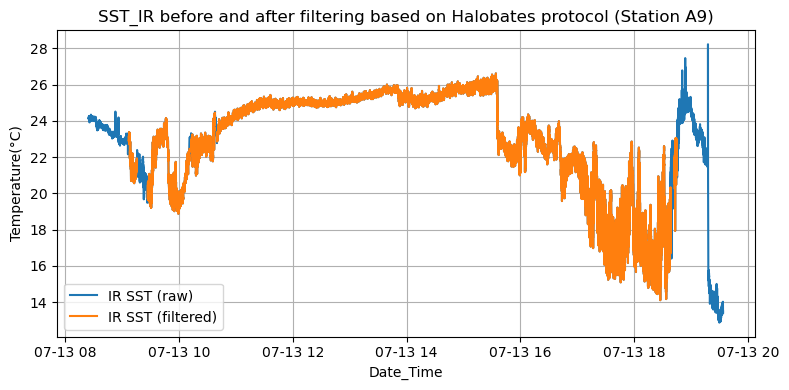

In [190]:
# Shift is the number of seconds before the scheduled start to define the "clean" reference window
sst_cleaned = clean_sst_multideploy(df_sst, df_protocol, sst_variable="SST (°C)", shift_s=300) 

plt.figure(figsize=(8, 4))
plt.plot(df_sst['Time'], df_sst["SST (°C)"], label='IR SST (raw)')
plt.plot(sst_cleaned['Time'], sst_cleaned["SST (°C)"], label='IR SST (filtered)')
plt.xlabel('Date_Time')
plt.ylabel('Temperature(°C)')
plt.title(f'SST_IR before and after filtering based on Halobates protocol (Station {ID})')
plt.legend(loc = "lower left")
plt.grid(True)
plt.tight_layout()

#plt.ylim(20, 30)

plt.show()

#### Remove futher peaks

In [133]:
# Remove further peaks using additional filters

# Mask values outside [min_val, max_val] by setting them to NaN.
def clip_data(series: pd.Series, min_val: float, max_val: float) -> pd.Series:
    """
    Mask values outside [min_val, max_val] by setting them to NaN.
    """
    return series.where(series.between(min_val, max_val))

# Compute a symmetric Exponentially Weighted Moving Average (EWMA) by forward and backward passes.
def ewma_forward_backward(series: pd.Series, span: int) -> pd.Series:
    """
    Compute a symmetric EWMA by forward and backward passes.
    """
    fwd = series.ewm(span=span, adjust=False).mean()
    bwd = series[::-1].ewm(span=span, adjust=False).mean()[::-1]
    return (fwd + bwd) / 2

# Remove points that deviate from reference by more than delta.
def remove_delta_outliers(series: pd.Series, reference: pd.Series, delta: float) -> pd.Series:
    """
    Mask points that deviate from reference by more than delta.
    """
    return series.mask((series - reference).abs() > delta)

# Remove values beyond num_std standard deviations from the mean.
def remove_std_outliers(series: pd.Series, num_std: float) -> pd.Series:
    """
    Mask values beyond num_std standard deviations from the mean.
    """
    m, s = series.mean(), series.std()
    return series.mask((series - m).abs() > num_std * s)

In [178]:
# === Apply all functions to remove peaks
min_sst = 25  # Define a minimum SST value to clip
max_sst = 28  # Define a maximum SST value to clip

sst_removepeaks = sst_cleaned.copy()
sst_removepeaks['y_clipped']       = clip_data(sst_removepeaks['SST (\u00b0C)'], min_sst, max_sst)
sst_removepeaks['y_ewma_fb']       = ewma_forward_backward(sst_removepeaks['y_clipped'], span=100)
sst_removepeaks['y_no_delta']      = remove_delta_outliers(sst_removepeaks['y_clipped'], sst_removepeaks['y_ewma_fb'], delta=0.5)
sst_removepeaks['y_no_peaks']      = remove_std_outliers(sst_removepeaks['y_no_delta'], num_std=4)

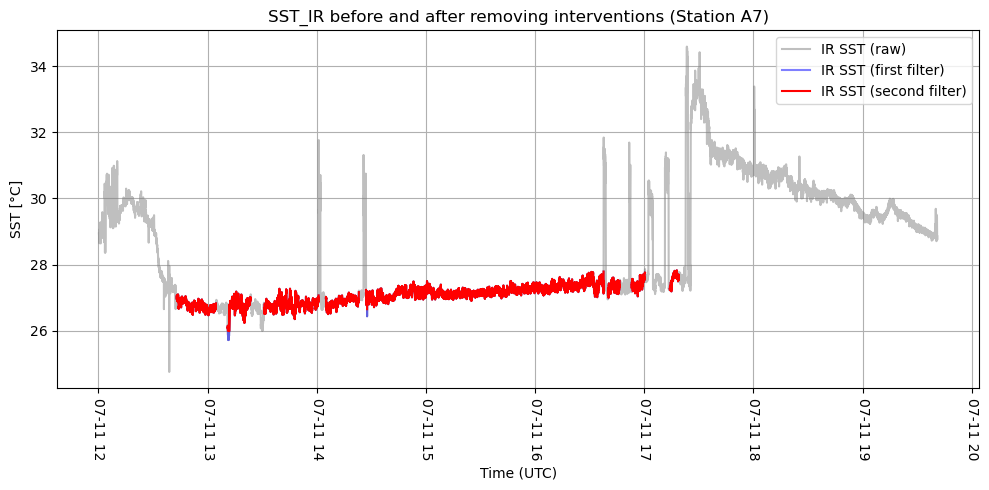

In [180]:
# PLOT
plt.figure(figsize=(10, 5))
plt.plot(df_sst["Time"], df_sst["SST (°C)"], label='IR SST (raw)', color='gray', alpha=0.5)
plt.plot(sst_removepeaks["Time"], sst_removepeaks["SST (°C)"], alpha=0.5, label='IR SST (first filter)', color='blue')
plt.plot(sst_removepeaks["Time"], sst_removepeaks['y_no_peaks'], label='IR SST (second filter)', color='red')


plt.xlabel("Time (UTC)")
plt.ylabel("SST [°C]")
plt.title(f"SST_IR before and after removing interventions (Station {ID})")
plt.xticks(rotation=-90)

#plt.ylim(20, 30)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(plots_dir / "SST_nopeaks" / f"SST_IR_filtered_{ID}.png", dpi=300)
plt.show()

### Compare with Halobates SML temperature

C:\Users\ludog\AppData\Local\Temp\ipykernel_21284\1909318527.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_halo = pd.read_csv(halobates_file, parse_dates=['Date_Time'])


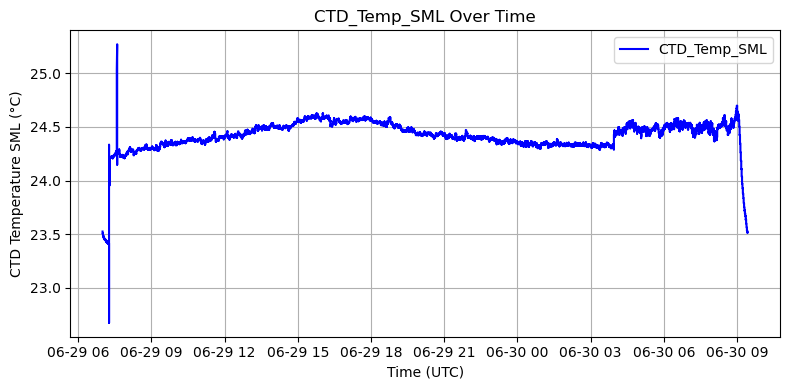

In [100]:
# Load Halobates data
df_halo = pd.read_csv(halobates_file, parse_dates=['Date_Time'])

# Rename time column for consistency    
df_halo  = df_halo.rename(columns={'Date_Time': 'Time'})

# Plot SML temperature 
plt.figure(figsize=(8, 4))
plt.plot(df_halo['Time'], df_halo['CTD_Temp_SML'], label='CTD_Temp_SML', color='blue')
plt.xlabel('Time (UTC)')
plt.ylabel('CTD Temperature SML (°C)')
plt.title('CTD_Temp_SML Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [102]:
# Apply same filtering based on Halobates protocol to Habolates SML temperature -> this we don't really need as H
# keeps measuring also during intervention times
#halo_sml_temp = clean_sst(df_halo, df_protocol, sst_variable="CTD_Temp_SML", shift_s=300)

df_halo['Time'] = pd.to_datetime(df_halo['Time'])
df_temp = df_halo.set_index('Time').sort_index()

#IMP: Halobates dataset does not have seconds in the time (for some weird reason), so for each minute
# there are 60 measurements. Need to add seconds manually

# 1) Parse the minute‐only timestamp in df_halo
df_halo['Time'] = pd.to_datetime(df_halo['Time'], format='%Y-%m-%d %H:%M')

# 2) Within each minute, assign a 0–59 seconds offset
df_halo['second'] = df_halo.groupby('Time').cumcount()

# 3) Add that offset to build full per‐second timestamps
df_halo['Time'] = df_halo['Time'] + pd.to_timedelta(df_halo['second'], unit='s')

# 4) Drop the helper column
df_halo = df_halo.drop(columns=['second'])

print(df_halo['Time'].head())
print("\nAdded seconds to Halobates timestamps.")


0   2025-06-29 07:00:00
1   2025-06-29 07:00:01
2   2025-06-29 07:00:02
3   2025-06-29 07:00:03
4   2025-06-29 07:00:04
Name: Time, dtype: datetime64[ns]

Added seconds to Halobates timestamps.


In [103]:
# Apply std filter to Halobates SML temperature data
df_halo["CTD_Temp_SML_no_peaks"] = remove_std_outliers(df_halo["CTD_Temp_SML"], num_std=4)

#Clip Halobates data to IR camera data
non_na = sst_removepeaks.dropna(subset=['y_no_peaks'])
start_time = non_na['Time'].min()
end_time   = non_na['Time'].max()

mask = (df_halo['Time'] >= start_time) & (df_halo['Time'] <= end_time)
df_halo_clipped = df_halo.loc[mask].copy()
df_halo_clipped.reset_index(drop=True, inplace=True)

# Remove first and last Nans from SST data as well 
mask2 = (sst_removepeaks['Time'] >= start_time) & (sst_removepeaks['Time'] <= end_time)
sst_cleaned_clipped = sst_removepeaks.loc[mask2].copy()
sst_cleaned_clipped.reset_index(drop=True, inplace=True)



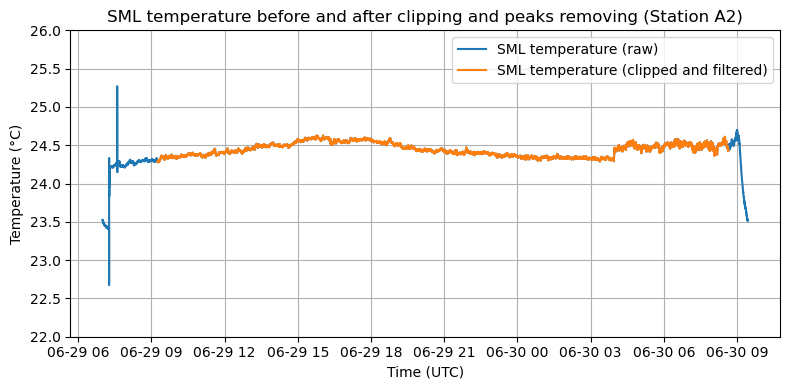

In [104]:
plt.figure(figsize=(8, 4))
plt.plot(df_halo['Time'], df_halo["CTD_Temp_SML"], label='SML temperature (raw)')
plt.plot(df_halo_clipped['Time'], df_halo_clipped['CTD_Temp_SML_no_peaks'], label='SML temperature (clipped and filtered)')
plt.xlabel('Time (UTC)')
plt.ylabel('Temperature (°C)')
plt.title(f'SML temperature before and after clipping and peaks removing (Station {ID})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(22, 26)
plt.savefig(plots_dir / "SST_SML_temperature" / f"SML_temp_clipped_{ID}.png", dpi=300)
plt.show()

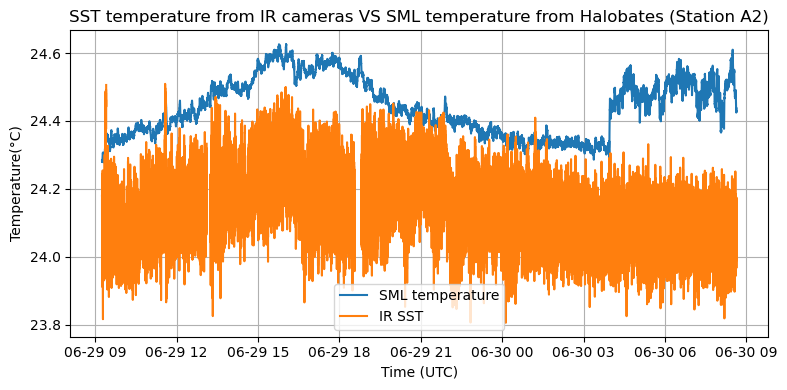

In [105]:
# Compare Halobates SML temperature with SST after removing peaks

plt.figure(figsize=(8, 4))
plt.plot(df_halo_clipped['Time'], df_halo_clipped['CTD_Temp_SML_no_peaks'], label='SML temperature')
plt.plot(sst_cleaned_clipped['Time'], sst_cleaned_clipped["y_no_peaks"], label='IR SST')
plt.xlabel('Time (UTC)')
plt.ylabel('Temperature(°C)')
plt.title(f'SST temperature from IR cameras VS SML temperature from Halobates (Station {ID})')
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.ylim(22, 26)
plt.savefig(plots_dir / "SST_SML_temperature" / f"SST_IR_vs_SML_filtered_{ID}.png", dpi=300)
plt.show()


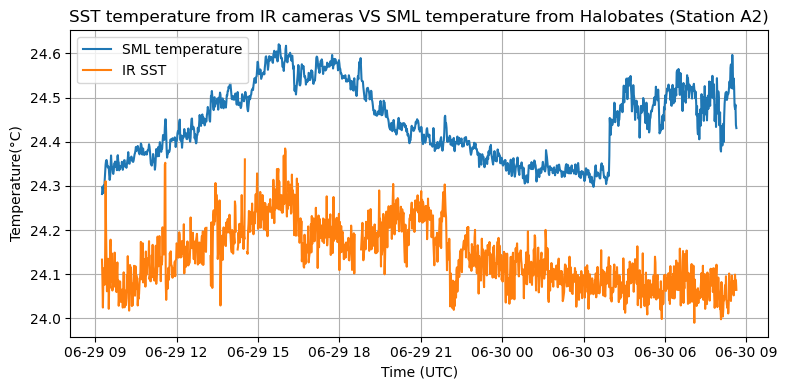

In [106]:
# Calculate 1 minute averages
sst_cleaned_avg = sst_cleaned_clipped.set_index('Time').resample('1min').mean().reset_index()
df_halo_avg = df_halo_clipped.set_index('Time').resample('1min').mean().reset_index()


plt.figure(figsize=(8, 4))
plt.plot(df_halo_avg['Time'], df_halo_avg['CTD_Temp_SML_no_peaks'], label='SML temperature')
plt.plot(sst_cleaned_avg['Time'], sst_cleaned_avg["y_no_peaks"], label='IR SST')
plt.xlabel('Time (UTC)')
plt.ylabel('Temperature(°C)')
plt.title(f'SST temperature from IR cameras VS SML temperature from Halobates (Station {ID})')
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.ylim(22, 26)
plt.savefig(plots_dir / "SST_SML_temperature" / f"SST_IR_vs_SML_filtered_1minavg_{ID}.png", dpi=300)
plt.show()


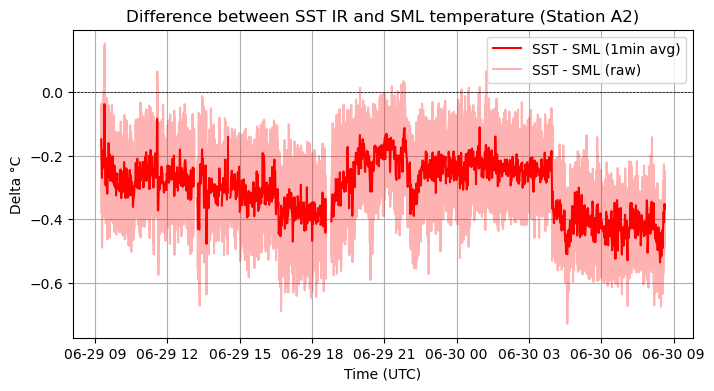

In [107]:
# Compute difference between SST and SML temperature both 1min average and raw
diff_avg = sst_cleaned_avg["y_no_peaks"] - df_halo_avg["CTD_Temp_SML_no_peaks"]
diff = sst_cleaned_clipped["y_no_peaks"] - df_halo_clipped["CTD_Temp_SML_no_peaks"]

plt.figure(figsize=(8, 4))
plt.plot(sst_cleaned_avg['Time'], diff_avg, label='SST - SML (1min avg)', color='red')
plt.plot(sst_cleaned_clipped['Time'], diff, label='SST - SML (raw)', color='red', alpha=0.3)
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)

plt.xlabel('Time (UTC)')
plt.ylabel('Delta °C')
plt.title(f'Difference between SST IR and SML temperature (Station {ID})')

plt.grid(True)
plt.legend()
plt.savefig(plots_dir / "SST_SML_temperature" / f"SST_IR_vs_SML_diff_{ID}.png", dpi=300)
plt.show()


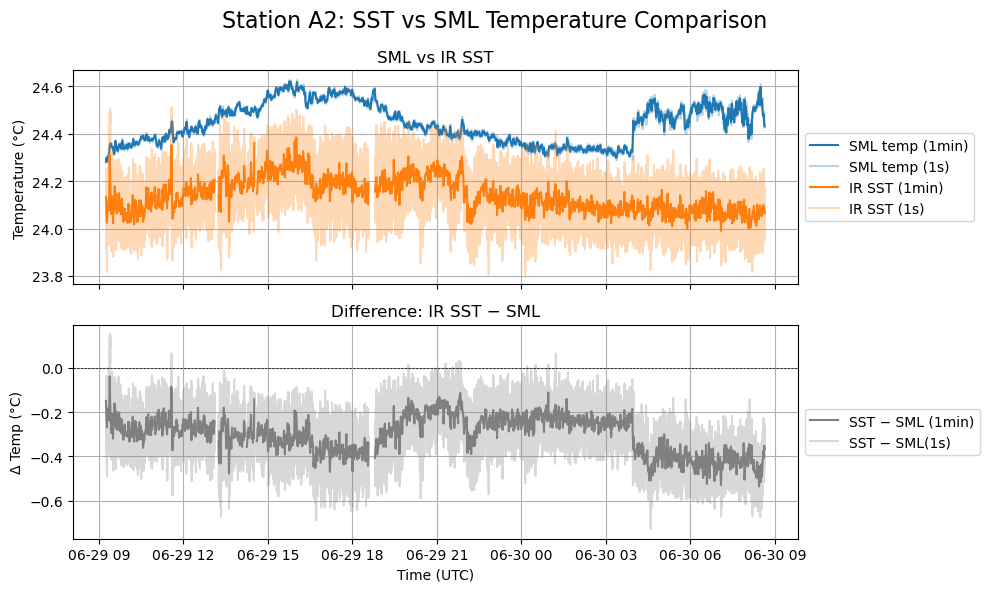

In [108]:
# Get colors 
colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:3]

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True)

# Top subplot: SML vs IR SST
axes[0].plot(df_halo_avg['Time'], df_halo_avg['CTD_Temp_SML_no_peaks'], label='SML temp (1min)')
axes[0].plot(df_halo_clipped['Time'], df_halo_clipped['CTD_Temp_SML_no_peaks'], c=colors[0], label='SML temp (1s)', alpha=0.3)
axes[0].plot(sst_cleaned_avg['Time'], sst_cleaned_avg['y_no_peaks'], label='IR SST (1min)')
axes[0].plot(sst_cleaned_clipped['Time'], sst_cleaned_clipped["y_no_peaks"], c=colors[1], label='IR SST (1s)', alpha=0.3)
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('SML vs IR SST')
axes[0].grid(True)
axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))

# Bottom subplot: Difference SST − SML
axes[1].plot(sst_cleaned_avg['Time'], diff_avg, label='SST − SML (1min)', color='grey')
axes[1].plot(sst_cleaned_clipped['Time'], diff, label='SST − SML(1s)', color='grey', alpha=0.3)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[1].set_ylabel('Δ Temp (°C)')
axes[1].set_title('Difference: IR SST − SML')
axes[1].grid(True)
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

axes[1].set_xlabel('Time (UTC)')
plt.suptitle(f"Station {ID}: SST vs SML Temperature Comparison", fontsize=16)
plt.tight_layout()
plt.savefig(plots_dir / "SST_SML_temperature" / f"SST_IR_vs_SML_comparison_{ID}.png", dpi=300, bbox_inches='tight')
plt.show()


### Save data 

In [109]:
# Merge all relevant series on 'Time'
merged = pd.DataFrame({'Time': pd.to_datetime(df_sst['Time'])})
merged = merged.merge(df_sst[['Time', 'SST (°C)']], on='Time', how='outer')  # raw SST
merged = merged.merge(sst_removepeaks[['Time', 'y_no_peaks']], on='Time', how='outer')  # filtered SST
merged = merged.merge(df_halo[['Time', 'CTD_Temp_SML']], on='Time', how='outer')  # raw SML
merged = merged.merge(df_halo[['Time', 'CTD_Temp_SML_no_peaks']], on='Time', how='outer')  # filtered SML

# Calculate difference (filtered SST - filtered SML)
merged['SST_minus_SML'] = merged['y_no_peaks'] - merged['CTD_Temp_SML_no_peaks']

# Remove first na values 
columns_to_check = [col for col in merged.columns if col != 'Time']
first_valid_idx = merged[columns_to_check].notna().any(axis=1).idxmax()
merged = merged.iloc[first_valid_idx:].copy()

# Rename colums
merged = merged.rename(columns={
    'SST (°C)': 'SST_raw (°C)',
    'y_no_peaks': 'SST_filtered (°C)',
    'CTD_Temp_SML': 'SML_raw (°C)',
    'CTD_Temp_SML_no_peaks': 'SML_filtered (°C)',
    'SST_minus_SML': 'SST_minus_SML_filtered (°C)'
})

# Save to CSV
merged.to_csv(results_dir / "data" / "SST_SML_postprocessed" / f"SST_SML_1s_{ID}.csv", index=False)
print("Saved merged SST/SML data to CSV.")

Saved merged SST/SML data to CSV.


In [110]:
# Create and update table with statistics about the difference between SST and SML temperature

# Calculate mean and std of the difference (filtered, 1min average)
mean_diff_avg = round(diff_avg.mean(), 5)
std_diff_avg = round(diff_avg.std(), 5)
mean_diff = round(diff.mean(), 5)
std_diff = round(diff.std(), 5)

# Prepare summary row
summary_row = {
    'Station_ID': ID,
    'SST - SML Mean_Diff_1s (°C)': mean_diff,
    'SST - SML Std_Diff_1s (°C) ': std_diff, 
    'SST - SML Mean_Diff_1min (°C)': mean_diff_avg,
    'SST - SML Std_Diff_1min (°C)': std_diff_avg
}

# Path for summary table
summary_path = results_dir / "data" / "SST_SML_postprocessed" / "SST_SML_diff_summary.csv"

# Read and update table
if os.path.exists(summary_path):
    summary_df = pd.read_csv(summary_path)
    # Remove any existing row for this station
    summary_df = summary_df[summary_df['Station_ID'] != ID]
    # Append new row
    summary_df = pd.concat([summary_df, pd.DataFrame([summary_row])], ignore_index=True)
    
# If the file does not exist, create a new DataFrame
else:
    summary_df = pd.DataFrame([summary_row])

# Save summary table
summary_df.to_csv(summary_path, index=False)
print("Saved/updated summary statistics table.")

Saved/updated summary statistics table.
